In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np
from scipy.integrate import quad
import math
import matplotlib.pyplot as plt
from library.utils import fontstyle
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# Fridge Details

In [3]:
from library.fridges import TEMP_STAGES, FRIDGE_LIBRARY
# Assuming XLD1000sl
# We will use the operating temperatures and cable lengths corresponding to an XLD1000sl fridge
fridge = FRIDGE_LIBRARY["XLD1000SL"]
cooling_power_budget = fridge["cooling_power"]
operating_temp = fridge["temp"]
flange_separation = fridge["lengths"]

# Electrical Resitivity

In [4]:
# resistivity above 4K
# 2025raicuCryogenicThermalModeling

def hdw_resistivity(T):
    # Units = W/m.K
    # Assuming RRR = 50
    a = -8.327
    b = 10.012
    c = -52.833
    d = 122.547
    e = -152.760
    f = 109.033
    g = -44.416
    h = 9.598
    i = -0.854

    rho_hdw = 10**(
        a 
        + b*(np.log10(T)) 
        + c*(np.log10(T))**2
        + d*(np.log10(T))**3
        + e*(np.log10(T))**4
        + f*(np.log10(T))**5
        + g*(np.log10(T))**6
        + h*(np.log10(T))**7
        + i*(np.log10(T))**8
    )

    return rho_hdw

In [5]:
# Get data poitns
temp = np.linspace(4, 300, num=100)
values = hdw_resistivity(temp)

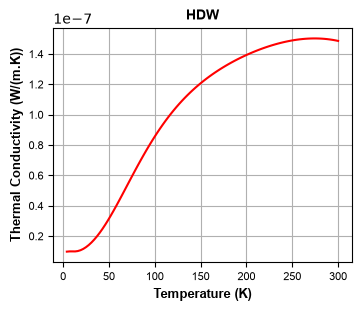

In [6]:
# Plot data

# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, 
                       ncols=1, 
                       figsize=(3.5, 3), 
                       constrained_layout=True)

ax.plot(temp, values, color='red')
ax.set_title("HDW", fontproperties=title_font)
ax.set_xlabel('Temperature (K)', fontproperties=axis_label_font)
ax.set_ylabel('Thermal Conductivity (W/(m.K))', fontproperties=axis_label_font)
for label in ax.get_yticklabels() :
        label.set_fontproperties(tick_label_font)

for label in ax.get_xticklabels() :
        label.set_fontproperties(tick_label_font)

ax.grid(True)
plt.grid(True)
plt.savefig(f"./hdw_electrical_resitivity.png",dpi=600)

plt.show()

In [7]:
from library.components import get_resistance

cable_diam = 0.203E-3
print("Resistance for HDW")
for temp_stage in TEMP_STAGES[1:3]:
    # get cable length
    cable_length = flange_separation[temp_stage] # cm
    
    # get operating temperatures
    current_temp_stage_idx = TEMP_STAGES.index(temp_stage)
    if current_temp_stage_idx > 0:
        prev_temp_stage = TEMP_STAGES[current_temp_stage_idx - 1]
    T_lo = operating_temp[temp_stage]
    T_hi = operating_temp[prev_temp_stage]

    # get_resistance() requires cable_length in meters
    resistance = get_resistance(hdw_resistivity, cable_length, cable_diam, T_lo, T_hi)
    print(f"{temp_stage}:\t {resistance:.2e} ohms")

Resistance for HDW
50K:	 1.72e-02 ohms
4K:	 2.06e-03 ohms


These values are not used in the modeling as their contributions is negligible compared to the cooling powers and the heat dissipated by other components (e.g., attenuators)

# Electrical Resitivity below 4K

In [8]:
# Below 3.8K, we assume resistivity is assumed constant (2025raicuCryogenicThermalModeling)
hdw_resistivity_sub4K = 9.928E-9 #ohm-meter

cable_diam = 0.203E-3
cable_area = np.pi * (cable_diam/2)**2

print("Resistance for HDW below 4K")
for temp_stage in TEMP_STAGES[3:]:
    # get cable length
    cable_length = flange_separation[temp_stage] * 1E-2 # cm --> m
    resistance = hdw_resistivity_sub4K * cable_length/ cable_area
    # print(f"{temp_stage}:\t {resistance:.4e} ohms")
    print(f"{temp_stage}:\t {resistance} ohms")

Resistance for HDW below 4K
Still:	 0.08512219200990727 ohms
CP:	 0.060275714342150524 ohms
MXC:	 0.060275714342150524 ohms


These values are used only for FLUX_BIAS and COUPLER lines in TF systems to model dissipation due to biasing currents flowing through them.